In [2]:
import pandas as pd

titles = pd.read_csv("titles.csv")
credits = pd.read_csv("credits.csv")

print("Titles shape:", titles.shape)
print("Credits shape:", credits.shape)

Titles shape: (9871, 15)
Credits shape: (124235, 5)


In [3]:
print("Titles columns:")
print(titles.columns.tolist())

print("\nFirst 5 titles:")
display(titles.head())

print("\nMovies and shows:")
display(titles["type"].value_counts())

print("\nRelease year range:")
print(titles["release_year"].min(), "to", titles["release_year"].max())

print("\nCredits by role:")
display(credits["role"].value_counts())

Titles columns:
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

First 5 titles:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6



Movies and shows:


type
MOVIE    8514
SHOW     1357
Name: count, dtype: int64


Release year range:
1912 to 2022

Credits by role:


role
ACTOR       115846
DIRECTOR      8389
Name: count, dtype: int64

In [4]:
print("Missing values in titles:")
print(titles.isna().sum())

print("\nMissing values in credits:")
print(credits.isna().sum())

print("\nExact duplicate title rows:", titles.duplicated().sum())
print("Duplicate title IDs:", titles["id"].duplicated().sum())
print("Exact duplicate credit rows:", credits.duplicated().sum())

Missing values in titles:
id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6487
runtime                    0
genres                     0
production_countries       0
seasons                 8514
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2082
dtype: int64

Missing values in credits:
person_id        0
id               0
name             0
character    16287
role             0
dtype: int64

Exact duplicate title rows: 3
Duplicate title IDs: 3
Exact duplicate credit rows: 56


In [5]:
titles_clean = titles.drop_duplicates().copy()
credits_clean = credits.drop_duplicates().copy()

print("Titles before:", titles.shape)
print("Titles after: ", titles_clean.shape)

print("\nCredits before:", credits.shape)
print("Credits after: ", credits_clean.shape)

print(
    "\nDuplicate title IDs remaining:",
    titles_clean["id"].duplicated().sum()
)

Titles before: (9871, 15)
Titles after:  (9868, 15)

Credits before: (124235, 5)
Credits after:  (124179, 5)

Duplicate title IDs remaining: 0


In [7]:
print("Missing seasons by title type:")
print(titles_clean.groupby("type")["seasons"]
    .apply(lambda values: values.isna().sum()))

print("\nMissing character by credit role:")
print(credits_clean.groupby("role")["character"]
    .apply(lambda values: values.isna().sum()))

Missing seasons by title type:
type
MOVIE    8511
SHOW        0
Name: seasons, dtype: int64

Missing character by credit role:
role
ACTOR       7891
DIRECTOR    8386
Name: character, dtype: int64


In [11]:
columns_to_check = [
    "age_certification",
    "imdb_score",
    "imdb_votes",
    "tmdb_popularity",
    "tmdb_score",
    "description"
]

missing_percent = (
    titles_clean[columns_to_check]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("Missing values by percentage:")
print(missing_percent)

Missing values by percentage:
age_certification    65.71
tmdb_score           21.08
imdb_votes           10.45
imdb_score           10.35
tmdb_popularity       5.54
description           1.21
dtype: float64


In [12]:
titles_eda = titles_clean.copy()

titles_eda["age_certification"] = (
    titles_eda["age_certification"].fillna("Not provided")
)

print("Missing age certifications left:", titles_eda["age_certification"].isna().sum())
print("\nAge certification counts:")
print(titles_eda["age_certification"].value_counts())

Missing age certifications left: 0

Age certification counts:
age_certification
Not provided    6484
R               1249
PG-13            588
PG               582
G                269
TV-MA            217
TV-14            188
TV-PG             91
TV-Y              78
TV-G              57
TV-Y7             52
NC-17             13
Name: count, dtype: int64


In [15]:
numeric_columns = [
    "release_year",
    "runtime",
    "seasons",
    "imdb_score",
    "imdb_votes",
    "tmdb_popularity",
    "tmdb_score"
]

summary = titles_clean[numeric_columns].describe().T
display(summary.round(2))

,count,mean,std,min,25%,50%,75%,max
release_year,9868.0,2001.35,25.79,1912.0,1996.00,2014.00,2018.00,2022.00
runtime,9868.0,85.98,33.52,1.0,65.00,89.00,102.00,549.00
seasons,1357.0,2.79,4.15,1.0,1.00,1.00,3.00,51.00
imdb_score,8847.0,5.98,1.34,1.1,5.10,6.10,6.90,9.90
imdb_votes,8837.0,8536.49,45927.68,5.0,118.00,464.00,2237.00,1133692.00
tmdb_popularity,9321.0,6.91,30.01,0.0,1.23,2.54,5.64,1437.91
tmdb_score,7788.0,5.98,1.52,0.8,5.10,6.00,6.90,10.00


In [16]:
movies = titles_clean[titles_clean["type"] == "MOVIE"]
shows = titles_clean[titles_clean["type"] == "SHOW"]

print("Movie runtime summary (minutes):")
display(movies["runtime"].describe().round(1))

print("\nShow episode runtime summary (minutes):")
display(shows["runtime"].describe().round(1))

print("\n10 longest runtimes:")
display(
    titles_clean.nlargest(10, "runtime")[
        ["title", "type", "runtime", "release_year"]
    ]
)

print("\nShows with the most seasons:")
display(
    shows.nlargest(10, "seasons")[
        ["title", "type", "seasons", "release_year"]
    ]
)


Movie runtime summary (minutes):


count    8511.0
mean       94.0
std        28.1
min         1.0
25%        80.0
50%        91.0
75%       105.0
max       549.0
Name: runtime, dtype: float64


Show episode runtime summary (minutes):


count    1357.0
mean       35.8
std        17.7
min         1.0
25%        23.0
50%        33.0
75%        47.0
max       153.0
Name: runtime, dtype: float64


10 longest runtimes:


,title,type,runtime,release_year
5227,9 Hours,MOVIE,549,2014
3137,Millennium,MOVIE,540,2010
904,Custer's Last Stand,MOVIE,328,1936
9821,Chhote Ustaad-Precaution Is Better Than Cure,MOVIE,300,2021
5174,Superfish,MOVIE,290,2013
7516,On the Trail of UFOs,MOVIE,268,2020
975,The Greatest Story Ever Told,MOVIE,260,1965
87,The Green Hornet,MOVIE,258,1940
1995,The Murder of Mary Phagan,MOVIE,251,1988
1004,1900,MOVIE,246,1976



Shows with the most seasons:


,title,type,seasons,release_year
1010,Great Performances,SHOW,51.0,1971
986,NOVA,SHOW,49.0,1974
2217,Survivor,SHOW,42.0,2000
1854,Home and Away,SHOW,35.0,1988
1903,The Bold and the Beautiful,SHOW,34.0,1987
2238,The Real World,SHOW,33.0,1992
969,Mister Rogers' Neighborhood,SHOW,31.0,1968
2931,The Only Way Is Essex,SHOW,28.0,2010
0,The Three Stooges,SHOW,26.0,1934
4165,24 Hours in A&E,SHOW,26.0,2011


In [ ]:

movie_q1 = movies["runtime"].quantile(0.25)
movie_q3 = movies["runtime"].quantile(0.75)
movie_iqr = movie_q3 - movie_q1
movie_upper = movie_q3 + 1.5 * movie_iqr

movie_outliers = movies[movies["runtime"] > movie_upper]
print("Movie runtime upper limit:", movie_upper)
print("Possible movie outliers:", len(movie_outliers))
display(movie_outliers.nlargest(10, "runtime")[["title", "runtime"]])

show_q1 = shows["runtime"].quantile(0.25)
show_q3 = shows["runtime"].quantile(0.75)
show_iqr = show_q3 - show_q1
show_upper = show_q3 + 1.5 * show_iqr

show_outliers = shows[shows["runtime"] > show_upper]
print("\nShow episode runtime upper limit:", show_upper)
print("Possible show outliers:", len(show_outliers))
display(show_outliers.nlargest(10, "runtime")[["title", "runtime"]])

Movie runtime upper limit: 142.5
Possible movie outliers: 498


,title,runtime
5227,9 Hours,549
3137,Millennium,540
904,Custer's Last Stand,328
9821,Chhote Ustaad-Precaution Is Better Than Cure,300
5174,Superfish,290
7516,On the Trail of UFOs,268
975,The Greatest Story Ever Told,260
87,The Green Hornet,258
1995,The Murder of Mary Phagan,251
1004,1900,246



Show episode runtime upper limit: 83.0
Possible show outliers: 22


,title,runtime
1148,QB VII,153
1010,Great Performances,116
3205,Inspector De Luca,107
2012,Act of Will,100
1961,Hold the Dream,97
3976,La omicidi,94
2590,World War II: When Lions Roared,92
4623,Generation War,92
4630,The Great Train Robbery,91
4579,Endeavour,90


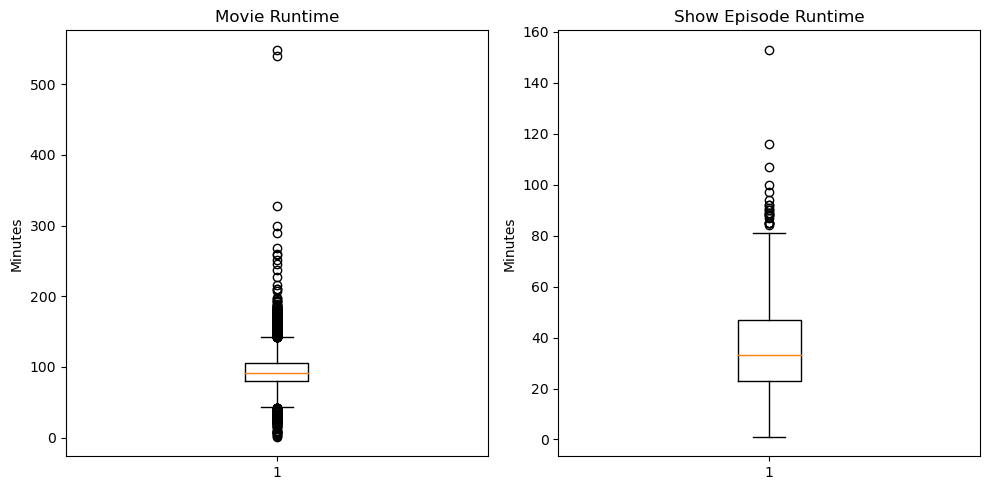

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(movies["runtime"].dropna())
axes[0].set_title("Movie Runtime")
axes[0].set_ylabel("Minutes")

axes[1].boxplot(shows["runtime"].dropna())
axes[1].set_title("Show Episode Runtime")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

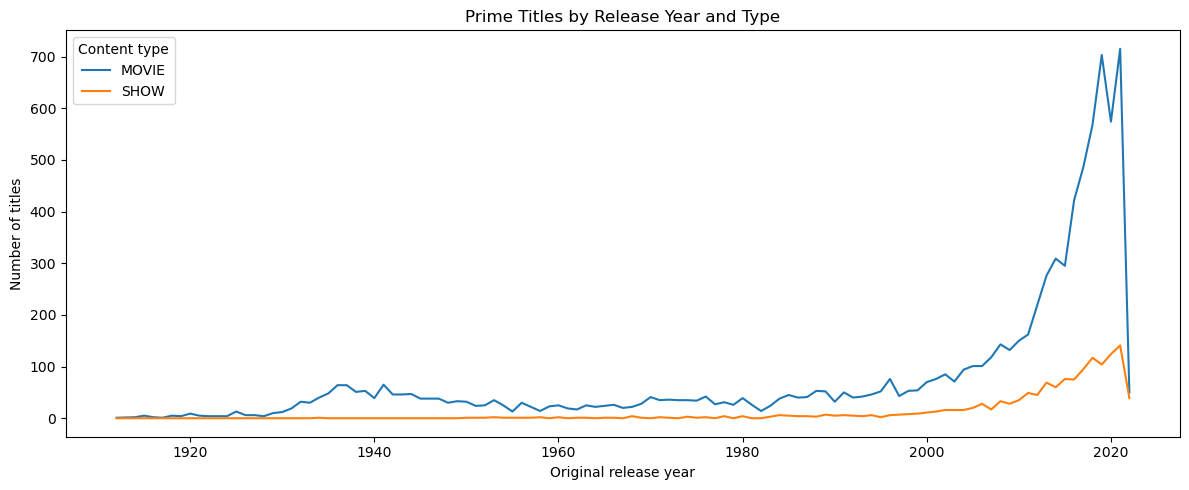

In [19]:
year_counts = (
    titles_clean.groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
)

year_counts.plot(figsize=(12, 5))
plt.title("Prime Titles by Release Year and Type")
plt.xlabel("Original release year")
plt.ylabel("Number of titles")
plt.legend(title="Content type")
plt.tight_layout()
plt.show()

In [20]:
display(year_counts.tail(8))

type,MOVIE,SHOW
release_year,,
2015,295,76
2016,422,75
2017,486,95
2018,568,117
2019,703,104
2020,574,124
2021,715,141
2022,50,39


In [21]:
import ast

titles_genres = titles_clean.copy()
titles_genres["genres"] = titles_genres["genres"].apply(ast.literal_eval)

all_genres = titles_genres.explode("genres")
genre_counts = all_genres["genres"].value_counts()

display(genre_counts.head(10))

genres
drama            4762
comedy           2987
thriller         2119
action           1820
romance          1751
crime            1250
documentation    1096
horror           1065
family            751
european          712
Name: count, dtype: int64

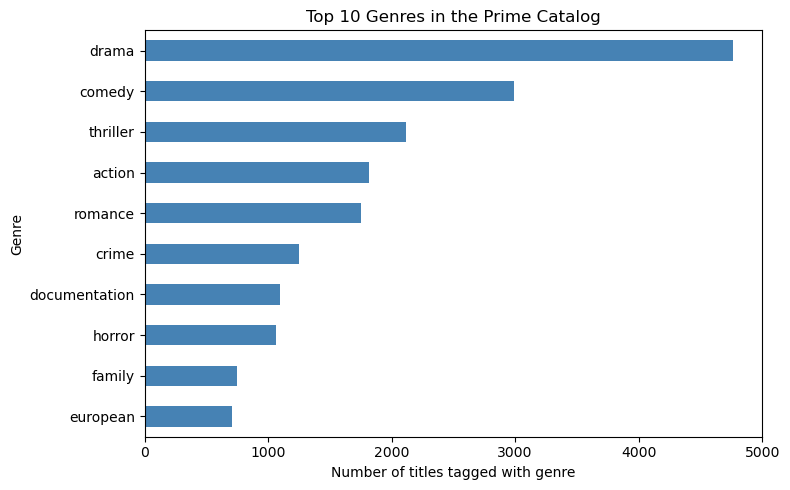

In [22]:
top_genres = genre_counts.head(10).sort_values()

top_genres.plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title("Top 10 Genres in the Prime Catalog")
plt.xlabel("Number of titles tagged with genre")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

In [23]:
genre_scores = (
    all_genres.groupby("genres")["imdb_score"]
    .agg(["mean", "count"])
)

# Bahut kam rated titles wale genres ko comparison se hata rahe hain
genre_scores = genre_scores[genre_scores["count"] >= 50]
genre_scores = genre_scores.sort_values("mean", ascending=False)

display(genre_scores.head(10).round(2))

,mean,count
genres,,
documentation,6.99,949
history,6.81,379
reality,6.75,129
animation,6.51,434
sport,6.44,224
war,6.40,316
european,6.31,698
music,6.20,395
family,6.15,724


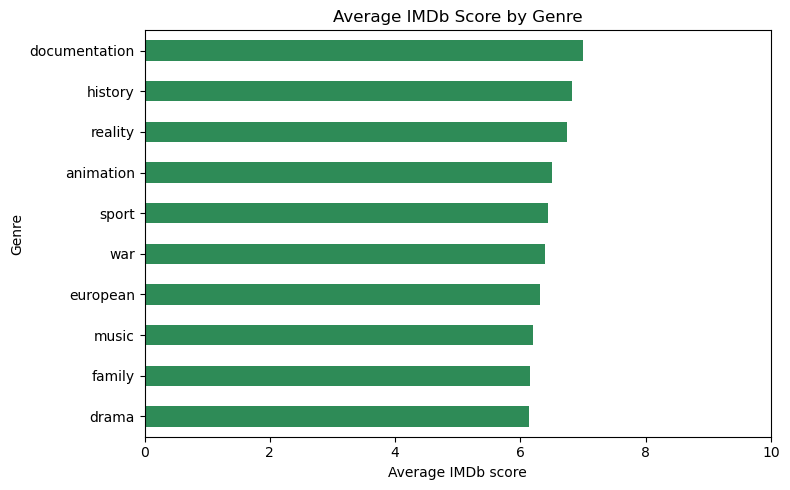

In [24]:
top_rated_genres = genre_scores.head(10)["mean"].sort_values()

top_rated_genres.plot(kind="barh", figsize=(8, 5), color="seagreen")
plt.title("Average IMDb Score by Genre")
plt.xlabel("Average IMDb score")
plt.ylabel("Genre")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

In [25]:
type_rating_summary = (
    titles_clean.groupby("type")["imdb_score"]
    .agg(["mean", "median", "count"])
)

display(type_rating_summary.round(2))

,mean,median,count
type,,,
MOVIE,5.80,5.9,7681
SHOW,7.12,7.3,1166


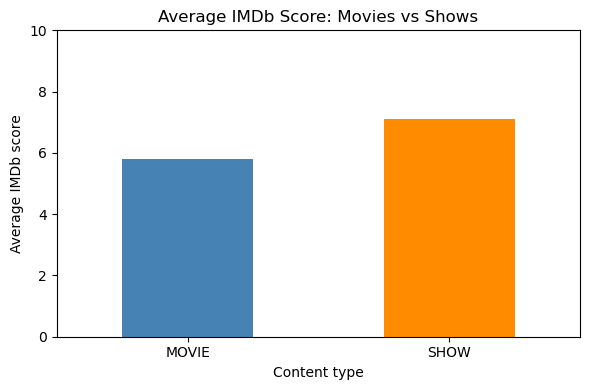

In [26]:
type_rating_summary["mean"].plot(
    kind="bar",
    figsize=(6, 4),
    color=["steelblue", "darkorange"]
)

plt.title("Average IMDb Score: Movies vs Shows")
plt.xlabel("Content type")
plt.ylabel("Average IMDb score")
plt.ylim(0, 10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
directors = credits_clean[credits_clean["role"] == "DIRECTOR"]

director_title_counts = (
    directors.groupby("name")["id"]
    .nunique()
    .sort_values(ascending=False)
)

display(director_title_counts.head(10).to_frame("unique_titles_directed"))

,unique_titles_directed
name,
Joseph Kane,41
Sam Newfield,38
Jay Chapman,34
Lesley Selander,22
Harry L. Fraser,21
John English,21
William Nigh,20
Manny Rodriguez,17
Robert N. Bradbury,17


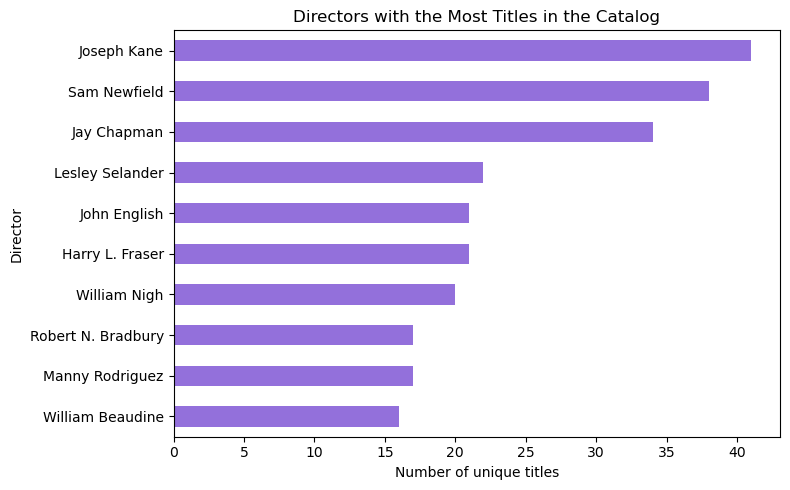

In [28]:
top_directors = director_title_counts.head(10).sort_values()

top_directors.plot(kind="barh", figsize=(8, 5), color="mediumpurple")
plt.title("Directors with the Most Titles in the Catalog")
plt.xlabel("Number of unique titles")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

In [29]:
actors = credits_clean[credits_clean["role"] == "ACTOR"]

actor_title_counts = (
    actors.groupby("name")["id"]
    .nunique()
    .sort_values(ascending=False)
)

display(actor_title_counts.head(10).to_frame("unique_titles_acted"))


,unique_titles_acted
name,
George 'Gabby' Hayes,49
Roy Rogers,45
Bess Flowers,44
Gene Autry,40
Nassar,37
Herman Hack,35
George Morrell,34
Earl Dwire,34
Forrest Taylor,34


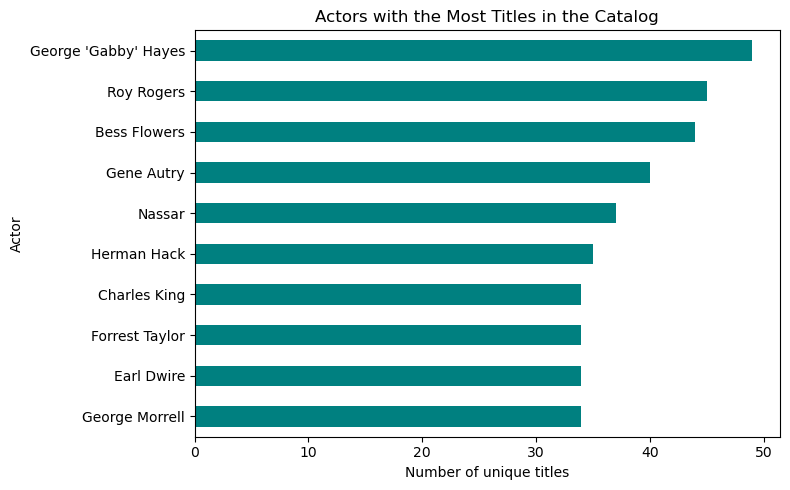

In [30]:
top_actors = actor_title_counts.head(10).sort_values()

top_actors.plot(kind="barh", figsize=(8, 5), color="teal")
plt.title("Actors with the Most Titles in the Catalog")
plt.xlabel("Number of unique titles")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()

In [31]:
titles_countries = titles_clean.copy()
titles_countries["production_countries"] = (
    titles_countries["production_countries"].apply(ast.literal_eval)
)

all_countries = titles_countries.explode("production_countries")
country_counts = all_countries["production_countries"].value_counts()

display(country_counts.head(10))

production_countries
US    5331
IN    1072
GB     928
CA     530
FR     250
JP     197
AU     173
DE     172
CN     143
IT     143
Name: count, dtype: int64

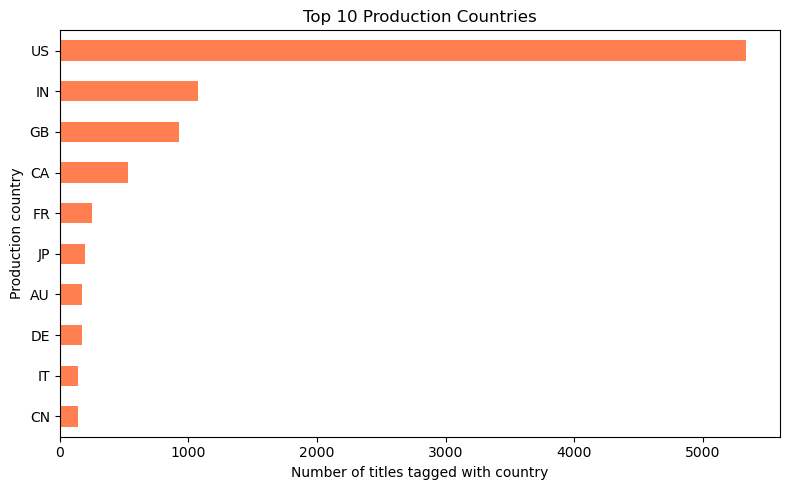

In [32]:
top_countries = country_counts.head(10).sort_values()

top_countries.plot(kind="barh", figsize=(8, 5), color="coral")
plt.title("Top 10 Production Countries")
plt.xlabel("Number of titles tagged with country")
plt.ylabel("Production country")
plt.tight_layout()
plt.show()

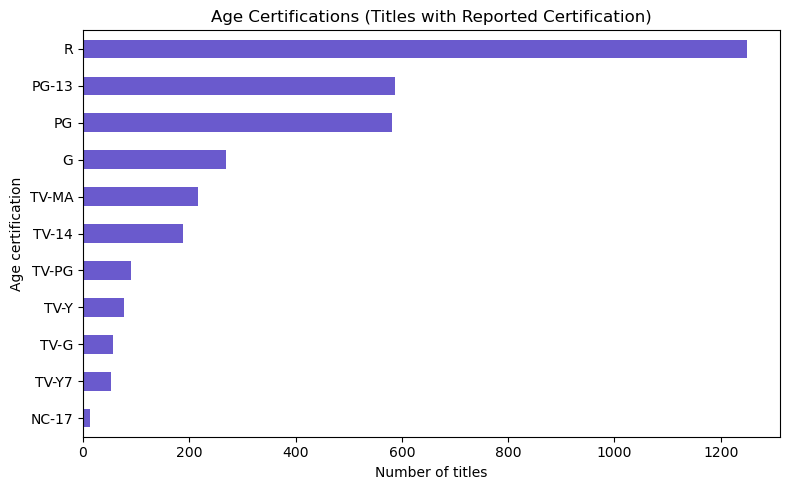

In [33]:
known_certifications = titles_eda[
    titles_eda["age_certification"] != "Not provided"
]

cert_counts = known_certifications["age_certification"].value_counts()

cert_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    color="slateblue"
)

plt.title("Age Certifications (Titles with Reported Certification)")
plt.xlabel("Number of titles")
plt.ylabel("Age certification")
plt.tight_layout()
plt.show()

In [34]:
print("Top 10 titles by IMDb votes:")
display(
    titles_clean.nlargest(10, "imdb_votes")[
        ["title", "type", "release_year", "imdb_score", "imdb_votes"]
    ]
)

print("\nTop 10 titles by TMDB popularity:")
display(
    titles_clean.nlargest(10, "tmdb_popularity")[
        ["title", "type", "release_year", "tmdb_score", "tmdb_popularity"]
    ]
)

Top 10 titles by IMDb votes:


,title,type,release_year,imdb_score,imdb_votes
2220,Titanic,MOVIE,1997,7.9,1133692.0
2230,The Usual Suspects,MOVIE,1995,8.5,1059480.0
2237,Braveheart,MOVIE,1995,8.4,1016629.0
2229,The Sixth Sense,MOVIE,1999,8.2,967864.0
1814,The Terminator,MOVIE,1984,8.1,841706.0
2810,Dexter,SHOW,2006,8.7,711566.0
4102,Skyfall,MOVIE,2012,7.8,684779.0
2824,District 9,MOVIE,2009,7.9,670344.0
5293,Arrival,MOVIE,2016,7.9,669220.0
2228,Fargo,MOVIE,1996,8.1,663221.0



Top 10 titles by TMDB popularity:


,title,type,release_year,tmdb_score,tmdb_popularity
8934,All the Old Knives,MOVIE,2022,6.0,1437.906
9040,Harina,SHOW,2022,5.5,951.863
9039,The eighth clause,MOVIE,2022,4.1,950.986
8964,Hotel Transylvania: Transformania,MOVIE,2022,7.1,934.545
7421,Sonic the Hedgehog,MOVIE,2020,7.4,893.650
8948,Clifford the Big Red Dog,MOVIE,2021,7.3,482.744
9092,Queen of Spades,MOVIE,2021,6.2,429.802
9011,Meander,MOVIE,2021,6.0,389.431
4099,Suits,SHOW,2011,8.1,356.533
5287,Better Call Saul,SHOW,2015,8.5,352.657


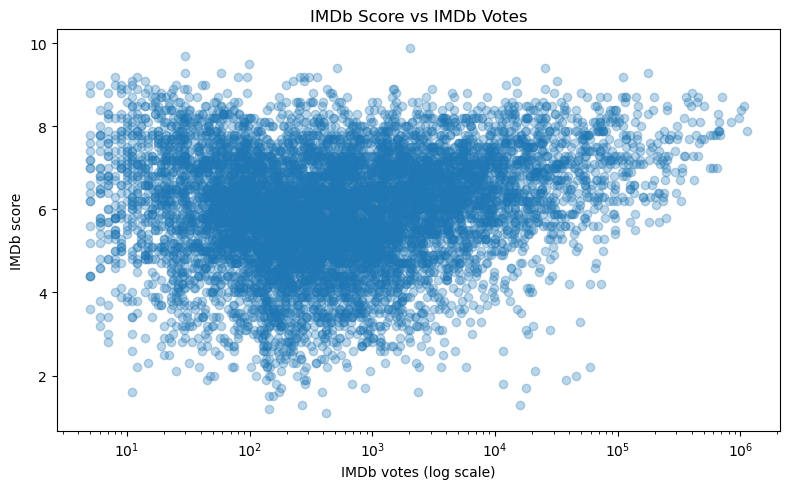

In [35]:
vote_score_data = titles_clean.dropna(
    subset=["imdb_votes", "imdb_score"]
)

plt.figure(figsize=(8, 5))
plt.scatter(
    vote_score_data["imdb_votes"],
    vote_score_data["imdb_score"],
    alpha=0.3
)

plt.xscale("log")
plt.title("IMDb Score vs IMDb Votes")
plt.xlabel("IMDb votes (log scale)")
plt.ylabel("IMDb score")
plt.tight_layout()
plt.show()

In [36]:
spearman_corr = vote_score_data["imdb_votes"].corr(
    vote_score_data["imdb_score"],
    method="spearman"
)

print("Spearman correlation:", round(spearman_corr, 3))

Spearman correlation: 0.143


In [37]:
both_scores = titles_clean.dropna(
    subset=["imdb_score", "tmdb_score"]
)

score_corr = both_scores["imdb_score"].corr(
    both_scores["tmdb_score"],
    method="spearman"
)

print("Titles with both scores:", len(both_scores))
print("IMDb vs TMDB Spearman correlation:", round(score_corr, 3))

Titles with both scores: 7319
IMDb vs TMDB Spearman correlation: 0.645


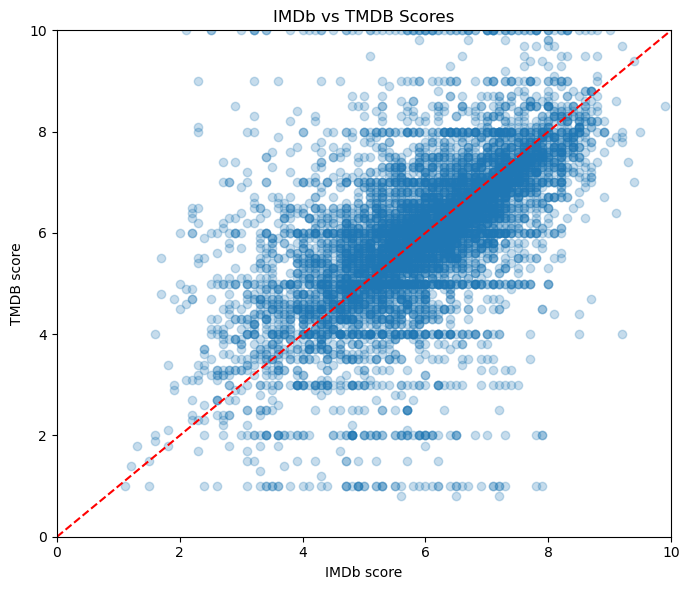

In [38]:
plt.figure(figsize=(7, 6))

plt.scatter(
    both_scores["imdb_score"],
    both_scores["tmdb_score"],
    alpha=0.25
)

plt.plot([0, 10], [0, 10], color="red", linestyle="--")

plt.title("IMDb vs TMDB Scores")
plt.xlabel("IMDb score")
plt.ylabel("TMDB score")
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

In [39]:
credits_with_titles = credits_clean.merge(
    titles_clean[["id", "title", "type", "release_year", "imdb_score"]],
    on="id",
    how="left",
    validate="many_to_one"
)

print("Credits before merge:", credits_clean.shape)
print("After adding title details:", credits_with_titles.shape)
print("Credits without a matching title:", credits_with_titles["title"].isna().sum())

display(credits_with_titles.head())

Credits before merge: (124179, 5)
After adding title details: (124179, 9)
Credits without a matching title: 0


,person_id,id,name,character,role,title,type,release_year,imdb_score
0,59401,ts20945,Joe Besser,Joe,ACTOR,The Three Stooges,SHOW,1934,8.6
1,31460,ts20945,Moe Howard,Moe,ACTOR,The Three Stooges,SHOW,1934,8.6
2,31461,ts20945,Larry Fine,Larry,ACTOR,The Three Stooges,SHOW,1934,8.6
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR,The General,MOVIE,1926,8.2
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR,The General,MOVIE,1926,8.2


In [40]:
director_credit_details = credits_with_titles[
    credits_with_titles["role"] == "DIRECTOR"
]

director_rating_summary = (
    director_credit_details.groupby("name")
    .agg(
        unique_titles=("id", "nunique"),
        rated_titles=("imdb_score", "count"),
        average_imdb_score=("imdb_score", "mean")
    )
)

eligible_directors = director_rating_summary[
    director_rating_summary["rated_titles"] >= 5
]

display(
    eligible_directors
    .sort_values("average_imdb_score", ascending=False)
    .head(10)
    .round(2)
)

,unique_titles,rated_titles,average_imdb_score
name,,,
Tony Charmoli,5,5,8.14
Hideaki Anno,5,5,7.50
William Wyler,11,11,7.47
Martin Scorsese,6,6,7.25
Angshuman Ghosh,5,5,7.24
Frank Capra,9,8,7.19
Alex Gibney,6,6,7.03
Manny Rodriguez,17,16,6.99
Stanley Donen,6,6,6.97


In [41]:
actor_credit_details = credits_with_titles[
    credits_with_titles["role"] == "ACTOR"
]

actor_rating_summary = (
    actor_credit_details.groupby("name")
    .agg(
        unique_titles=("id", "nunique"),
        rated_titles=("imdb_score", "count"),
        average_imdb_score=("imdb_score", "mean")
    )
)

eligible_actors = actor_rating_summary[
    actor_rating_summary["rated_titles"] >= 5
]

display(
    eligible_actors
    .sort_values("average_imdb_score", ascending=False)
    .head(10)
    .round(2)
)

,unique_titles,rated_titles,average_imdb_score
name,,,
'Poo' Ram,5,5,8.40
Mitzi Gaynor,8,7,8.03
Hiroaki Hirata,5,5,7.88
Ajay Ghosh,6,6,7.83
Mamiko Noto,6,6,7.78
Fahadh Faasil,5,5,7.78
Mariya Ise,6,6,7.77
Akio Otsuka,7,7,7.74
Muhammad Anas Abdul Aziz,1,5,7.70


In [42]:
actor_title_scores = actor_credit_details.drop_duplicates(
    subset=["person_id", "id"]
)

actor_rating_summary = (
    actor_title_scores.groupby(["person_id", "name"])
    .agg(
        unique_titles=("id", "nunique"),
        rated_titles=("imdb_score", "count"),
        average_imdb_score=("imdb_score", "mean")
    )
)

eligible_actors = actor_rating_summary[
    actor_rating_summary["rated_titles"] >= 5
]

display(
    eligible_actors
    .sort_values("average_imdb_score", ascending=False)
    .head(10)
    .round(2)
)

,,unique_titles,rated_titles,average_imdb_score
person_id,name,,,
203610,'Poo' Ram,5,5,8.40
56738,Mitzi Gaynor,8,7,8.03
60138,Hiroaki Hirata,5,5,7.88
184947,Ajay Ghosh,6,6,7.83
121,Mamiko Noto,6,6,7.78
162755,Fahadh Faasil,5,5,7.78
380,Mariya Ise,6,6,7.77
348,Akio Otsuka,7,7,7.74
1682,Giancarlo Esposito,6,5,7.70


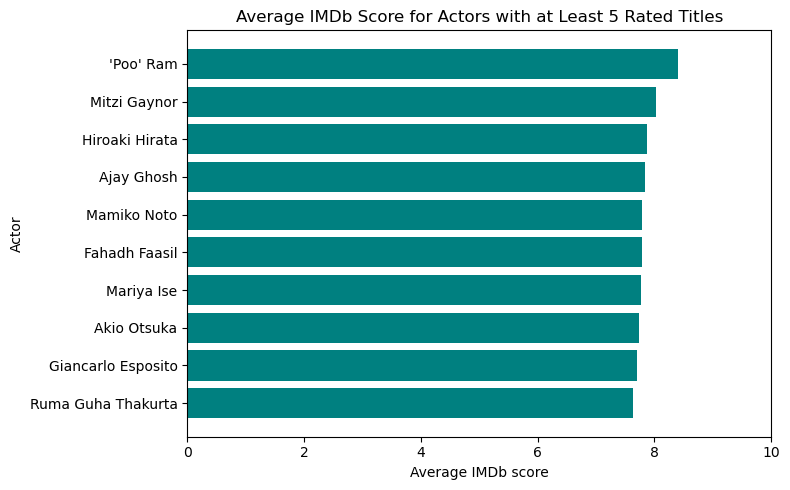

In [43]:
top_actor_ratings = (
    eligible_actors
    .sort_values("average_imdb_score", ascending=False)
    .head(10)
    .reset_index()
    .sort_values("average_imdb_score")
)

plt.figure(figsize=(8, 5))
plt.barh(
    top_actor_ratings["name"],
    top_actor_ratings["average_imdb_score"],
    color="teal"
)

plt.title("Average IMDb Score for Actors with at Least 5 Rated Titles")
plt.xlabel("Average IMDb score")
plt.ylabel("Actor")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

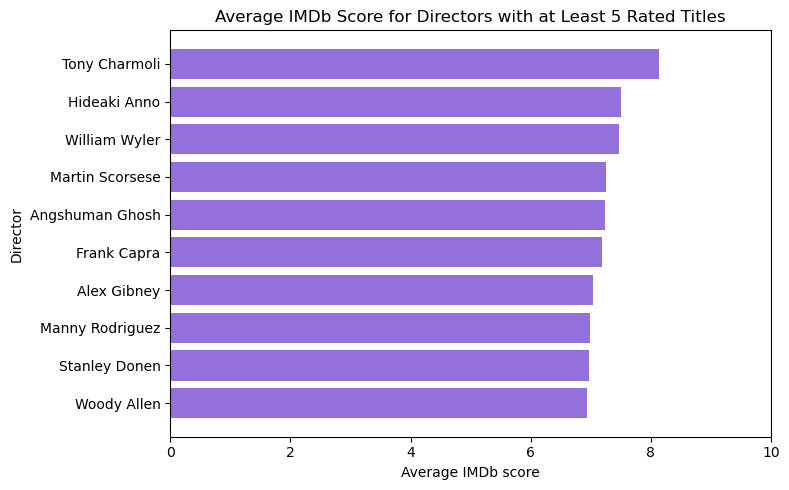

In [44]:
top_director_ratings = (
    eligible_directors
    .sort_values("average_imdb_score", ascending=False)
    .head(10)
    .reset_index()
    .sort_values("average_imdb_score")
)

plt.figure(figsize=(8, 5))
plt.barh(
    top_director_ratings["name"],
    top_director_ratings["average_imdb_score"],
    color="mediumpurple"
)

plt.title("Average IMDb Score for Directors with at Least 5 Rated Titles")
plt.xlabel("Average IMDb score")
plt.ylabel("Director")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

In [45]:
type_genre_scores = (
    all_genres.groupby(["type", "genres"])["imdb_score"]
    .agg(["mean", "count"])
)

type_genre_scores = type_genre_scores[
    type_genre_scores["count"] >= 50
]

top_genres_by_type = (
    type_genre_scores
    .sort_values("mean", ascending=False)
    .groupby(level="type")
    .head(5)
)

display(top_genres_by_type.round(2))

mean  count
type  genres                    
SHOW  history        7.75     77
      documentation  7.52    203
      european       7.44    116
      crime          7.33    145
      horror         7.32     50
MOVIE documentation  6.85    746
      history        6.58    302
      war            6.22    278
      sport          6.18    182
      music          6.16    367

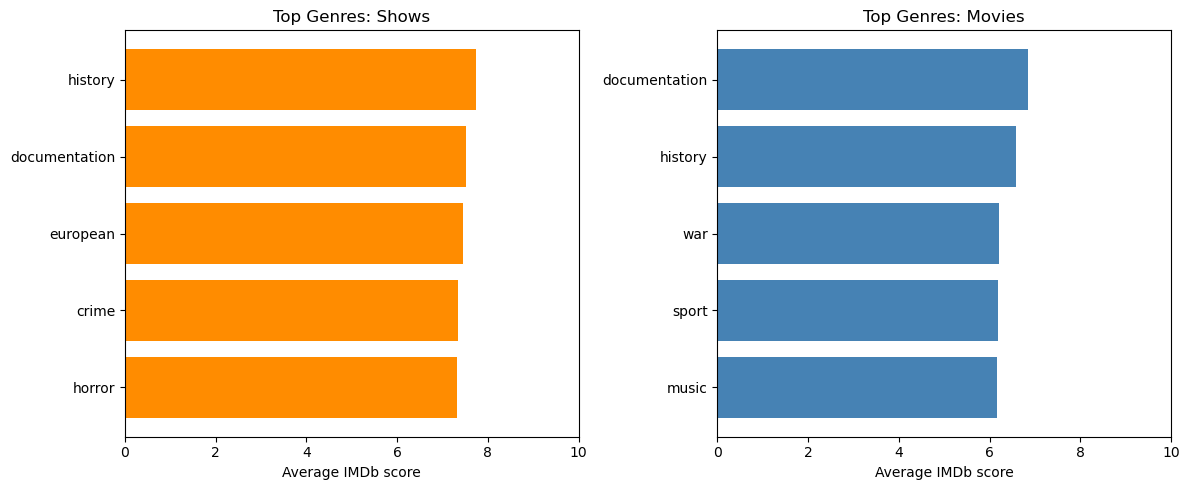

In [46]:
show_top = (
    type_genre_scores.loc["SHOW"]
    .sort_values("mean", ascending=False)
    .head(5)
    .sort_values("mean")
)

movie_top = (
    type_genre_scores.loc["MOVIE"]
    .sort_values("mean", ascending=False)
    .head(5)
    .sort_values("mean")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(show_top.index, show_top["mean"], color="darkorange")
axes[0].set_title("Top Genres: Shows")
axes[0].set_xlabel("Average IMDb score")
axes[0].set_xlim(0, 10)

axes[1].barh(movie_top.index, movie_top["mean"], color="steelblue")
axes[1].set_title("Top Genres: Movies")
axes[1].set_xlabel("Average IMDb score")
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.show()